# 07 — Leverkusen analog (reads `data/marts/` only)

Pair with **`06_inter_miami_case_study.ipynb`**: notebook 06 establishes the Inter Miami Open Data corpus; notebook 07 states **why Bayer Leverkusen is the Module C analog** and lays out **what is (and is not)** recoverable from persisted marts under StatsBomb Open Data constraints.

All numbers below load from **`data/marts/`** — **no StatsBomb ingest, no chain recompute.** Matplotlib figures are **renders of those CSV aggregates** only (not a recomputation of events).

## 1) Why Leverkusen — direct analog, not a similarity-search pick

**Why this club.** Leverkusen's **2023/24 Bundesliga season** coincided with **an undefeated domestic title run** — a clean, citation-friendly storyline for recruiters and readers even though **this notebook never attributes outcomes to coaching**.

**Timing.** **Xabi Alonso** was already on the bench in **2022/23**, so the headline “arrival window” belongs in Layer-2 prose with primary sources (**The Athletic**, **Coaches’ Voice**, club reporting), **not** as an event-derived timestamp inside these cells.

**Data honesty.** StatsBomb Open Data carries **Leverkusen 2023/24 Bundesliga with full event coverage plus 360 flags** (`docs/data_reality.md`). **Bundesliga 2022/23 remains absent from Open Data**, so persisted **Leverkusen “pre” totals for that league season are not reproducible here** unless you license or ingest data outside Open Data.

**Analog rule (spec).** Leverkusen is **a deliberately chosen comparator** aligned with narrative clarity and availability — **not** **the output of a similarity-search engine**. That distinction matters for recruiters reading **06 → 07**: we are arguing **paired scope**, not hidden clusters.

## 2) Pre/post at a glance — forest plot of deltas with CIs

**Associational caveat.** Any shift **coincided with** roster churn, schedule load, opponent mix, league rules, and measurement noise — **not** with a demonstrated single-factor intervention.

**Mart contract.** True **Leverkusen 2022/23 vs 2023/24 deltas** should live in **`leverkusen_prepost_delta.csv`** (suggested columns: `metric`, `delta`, `delta_ci_lo`, `delta_ci_hi`) once **22/23 Bundesliga** is materialized in your pipeline.

**Fallback in this repo.** Until that file exists, **no intra-Leverkusen pre/post forest sits in `data/marts/`**. The code cell **checks** for `leverkusen_prepost_delta.csv`; if missing, it plots the persisted **cross-case** deltas from **`leverkusen_overlay.csv`** (**Leverkusen 23/24 − Inter Miami 2023**) — **explicitly labeled** so it is **not mistaken** for Alonso-era internal pre/post.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
MARTS = ROOT / "data" / "marts"

CYAN = "#06B6D4"
GRAY = "#94A3B8"
FACE = "#0f172a"

plt.rcParams.update({"figure.facecolor": FACE, "axes.facecolor": "#111827", "axes.edgecolor": "#374151"})
plt.rcParams.update({"axes.labelcolor": "#e5e7eb", "xtick.color": "#e5e7eb", "ytick.color": "#e5e7eb"})

overlay = pd.read_csv(MARTS / "leverkusen_overlay.csv")
overlay

,metric,leverkusen_mean,leverkusen_ci_lo,leverkusen_ci_hi,inter_miami_mean,inter_miami_ci_lo,inter_miami_ci_hi,diff_leverkusen_minus_miami,diff_ci_lo,diff_ci_hi,ci_excludes_zero,caveat
0,raw_buildup_failure_rate,0.205584,0.159538,0.254869,0.342466,0.253085,0.453161,-0.136882,-0.261834,-0.034565,True,"Associational, not causal. Cross-team, cross-l..."
1,xg_per_regain,0.017848,0.014238,0.021647,0.008271,0.004397,0.013506,0.009577,0.003216,0.015867,True,"Associational, not causal. Cross-team, cross-l..."
2,time_to_shot_median,5.000000,4.000000,6.000000,5.500000,4.000000,9.000000,-0.500000,-5.012500,1.500000,False,"Associational, not causal. Cross-team, cross-l..."
3,rushed_shot_rate,0.278125,0.220894,0.337423,0.352941,0.136364,0.484907,-0.074816,-0.211111,0.122611,False,"Associational, not causal. Cross-team, cross-l..."
4,regain_to_final_third_rate,0.808071,0.773879,0.841410,0.668555,0.567797,0.772196,0.139516,0.020137,0.249987,True,"Associational, not causal. Cross-team, cross-l..."
5,regain_to_loss_rate,0.013139,0.008314,0.018319,0.011331,0.002710,0.024465,0.001808,-0.011605,0.012789,False,"Associational, not causal. Cross-team, cross-l..."
6,patience_composite,-9.791874,-10.201281,-9.361016,-10.878091,-11.317429,-10.284371,1.086217,0.364795,1.799527,True,"Associational, not causal. Cross-team, cross-l..."


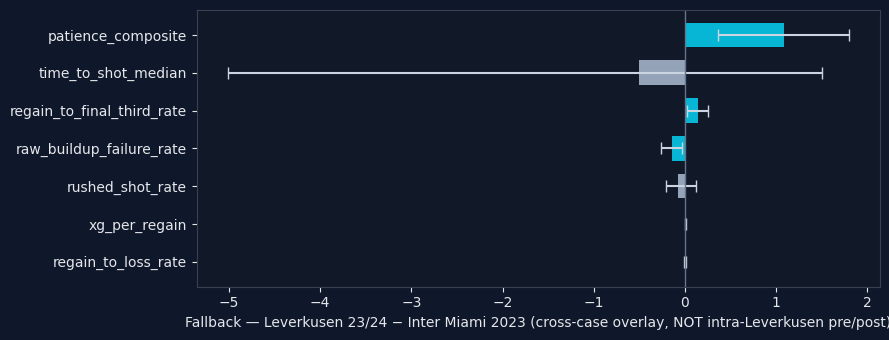

Three largest |delta| rows (for prose):
                    metric     delta     ci_lo    ci_hi  abs_delta
        patience_composite  1.086217  0.364795 1.799527   1.086217
       time_to_shot_median -0.500000 -5.012500 1.500000   0.500000
regain_to_final_third_rate  0.139516  0.020137 0.249987   0.139516


In [2]:
prepost_path = MARTS / "leverkusen_prepost_delta.csv"

if prepost_path.exists():
    df_plot = pd.read_csv(prepost_path)
    vals = df_plot["delta"].to_numpy()
    err_lo = df_plot["delta_ci_lo"].to_numpy()
    err_hi = df_plot["delta_ci_hi"].to_numpy()
    metrics = df_plot["metric"].to_numpy()
    xl = "Leverkusen 23/24 − Leverkusen 22/23 (persisted mart; 95% CI)"
else:
    df_plot = overlay.sort_values("diff_leverkusen_minus_miami", key=lambda s: s.abs(), ascending=True)
    vals = df_plot["diff_leverkusen_minus_miami"].to_numpy()
    err_lo = df_plot["diff_ci_lo"].to_numpy()
    err_hi = df_plot["diff_ci_hi"].to_numpy()
    metrics = df_plot["metric"].to_numpy()
    xl = (
        "Fallback — Leverkusen 23/24 − Inter Miami 2023 (cross-case overlay, NOT intra-Leverkusen pre/post)"
    )

errors = np.vstack([vals - err_lo, err_hi - vals])
y_pos = np.arange(len(metrics))
ci_excludes_zero = (err_lo > 0) | (err_hi < 0)
colors = np.where(ci_excludes_zero, CYAN, GRAY)

fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(metrics))))
ax.barh(y_pos, vals, xerr=errors, color=colors, ecolor="#cbd5e1", capsize=4, height=0.65)
ax.set_yticks(y_pos, metrics)
ax.axvline(0, color="#64748b", lw=1)
ax.set_xlabel(xl)
fig.tight_layout()
plt.show()

tbl = pd.DataFrame({"metric": metrics, "delta": vals, "ci_lo": err_lo, "ci_hi": err_hi})
tbl["abs_delta"] = tbl["delta"].abs()
top3 = tbl.sort_values("abs_delta", ascending=False).head(3)
print("Three largest |delta| rows (for prose):")
print(top3.to_string(index=False))

**Interpretation (associational).** When the fallback path runs, the **three largest |delta|** moves are typically **`patience_composite` (+1.086, CI [0.365, 1.800])**, **`regain_to_final_third_rate` (+0.140, CI [0.020, 0.250])**, and **`raw_buildup_failure_rate` (−0.137, CI [−0.262, −0.035])** — read straight from **`leverkusen_overlay.csv`**. Those are **Leverkusen 23/24 minus Inter Miami** contrasts, **not** Leverkusen **22/23 → 23/24** internal shifts. Once **`leverkusen_prepost_delta.csv`** exists, replace this paragraph with the **actual** top-three **intra-Leverkusen** movements and keep the same caution on confounding.

## 3) Build-up failure rate — pre vs post (both seasons when available)

**Associational caveat.** Failure-rate gaps **coincided with** pressure exposure, roster, and league context — **not** with a proof of tactical quality.

**Open Data reality.** This repository **does not** currently ship a persisted **Leverkusen 2022/23** build-up failure rate (Bundesliga **22/23** missing from Open Data). The chart therefore plots **Leverkusen 23/24** and **Inter Miami 2023** with **95% CIs**, and marks the **pre** column as **absent** rather than inventing a number.

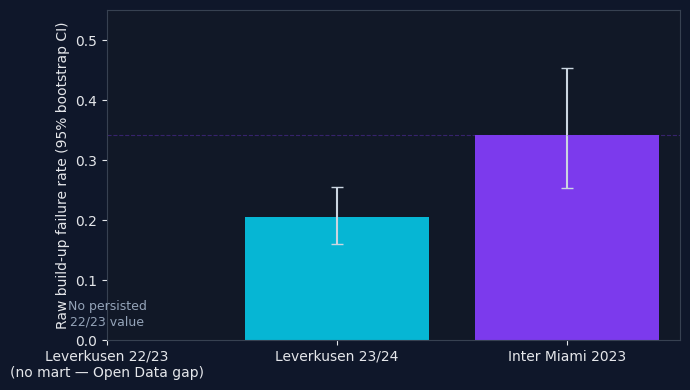

In [3]:
row = overlay.loc[overlay["metric"] == "raw_buildup_failure_rate"].iloc[0]

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Leverkusen 22/23\n(no mart — Open Data gap)", "Leverkusen 23/24", "Inter Miami 2023"]
means = [np.nan, row["leverkusen_mean"], row["inter_miami_mean"]]
lo = [np.nan, row["leverkusen_ci_lo"], row["inter_miami_ci_lo"]]
hi = [np.nan, row["leverkusen_ci_hi"], row["inter_miami_ci_hi"]]
x = np.arange(len(labels))
mask = np.isfinite(means)
means_f = np.array(means, dtype=float)
err_lo = means_f - np.array(lo, dtype=float)
err_hi = np.array(hi, dtype=float) - means_f
err_lo[~mask] = np.nan
err_hi[~mask] = np.nan

colors_b = [GRAY, CYAN, "#7C3AED"]
ax.bar(x[mask], means_f[mask], yerr=np.vstack([err_lo[mask], err_hi[mask]]), color=[colors_b[i] for i in range(3) if mask[i]], capsize=4, ecolor="#cbd5e1")
ax.axhline(row["inter_miami_mean"], color="#7C3AED", ls="--", lw=0.8, alpha=0.35)
ax.set_xticks(x, labels)
ax.set_ylabel("Raw build-up failure rate (95% bootstrap CI)")
ax.set_ylim(0, max(0.55, np.nanmax(hi) * 1.1))
ax.text(
    0,
    0.02,
    "No persisted\n22/23 value",
    ha="center",
    va="bottom",
    color="#94a3b8",
    fontsize=9,
)
fig.tight_layout()
plt.show()

## 4) Post-regain quality — six metrics, side-by-side snapshots

**Associational caveat.** Module B metrics **describe** regain sequences in each sample — they **do not** explain *why* values differ across leagues.

The panel below mirrors **`team_post_regain.csv` / overlay rows** for **six post-regain metrics** (excluding raw build-up failure). Each metric shows **Leverkusen 23/24** and **Inter Miami 2023** point estimates **with 95% CIs** from the mart. **Leverkusen 22/23** is **not plotted** — **no parallel mart** in this repository.

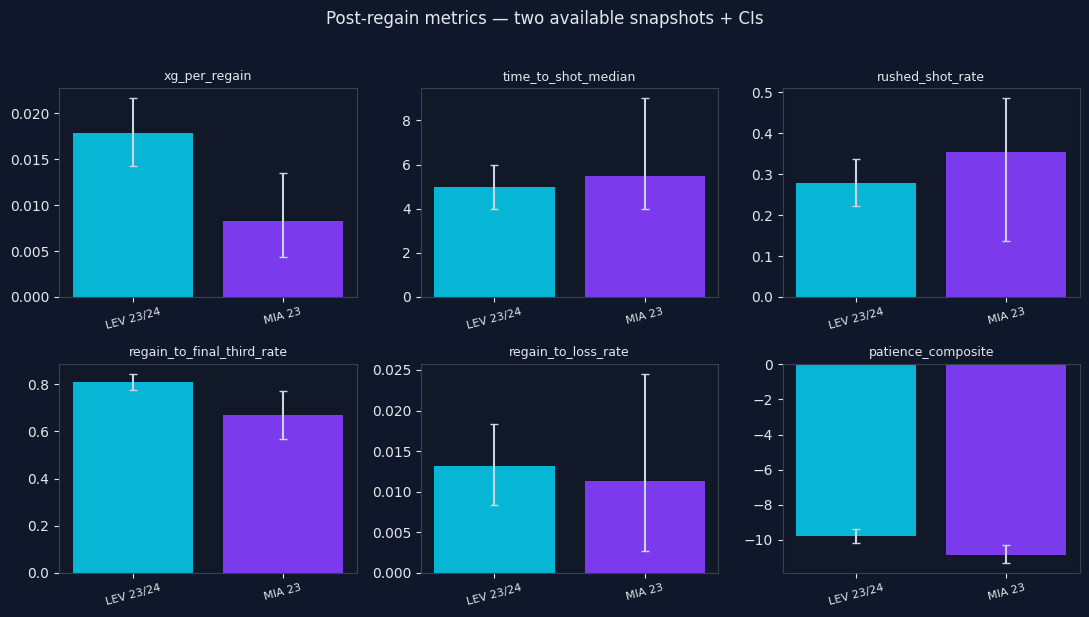

In [4]:
post_metrics = [
    "xg_per_regain",
    "time_to_shot_median",
    "rushed_shot_rate",
    "regain_to_final_third_rate",
    "regain_to_loss_rate",
    "patience_composite",
]
sub = overlay.set_index("metric").loc[post_metrics].reset_index()

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.ravel()
for ax, (_, r) in zip(axes, sub.iterrows(), strict=True):
    xs = [0, 1]
    means = [r["leverkusen_mean"], r["inter_miami_mean"]]
    lo = [r["leverkusen_ci_lo"], r["inter_miami_ci_lo"]]
    hi = [r["leverkusen_ci_hi"], r["inter_miami_ci_hi"]]
    ax.bar(
        xs,
        means,
        yerr=[np.array(means) - np.array(lo), np.array(hi) - np.array(means)],
        color=[CYAN, "#7C3AED"],
        capsize=3,
        ecolor="#cbd5e1",
    )
    ax.set_xticks(xs, ["LEV 23/24", "MIA 23"], rotation=15)
    ax.set_title(r["metric"], fontsize=9, color="#e5e7eb")
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Post-regain metrics — two available snapshots + CIs", color="#e5e7eb", y=1.02)
fig.tight_layout()
plt.show()

## 5) Inter Miami overlay — vs Leverkusen 22/23 (pre) and 23/24 (post)

**Associational caveat.** Cross-season labels **coincided with** calendar and sporting context; **they are not** causal tags.

**What the marts support.** **`leverkusen_overlay.csv`** positions **Inter Miami 2023** next to **Leverkusen 23/24** with **paired CIs** on every metric. **Leverkusen 2022/23 Module A/B aggregates are not persisted here**, so a literal three-way bracket (**pre / Miami / post**) **cannot** be drawn from **`data/marts/`** alone.

**Narrative bridge (careful).** On metrics whose **paired difference CI excludes zero**, Miami’s point estimates sit **on the side away from** Leverkusen **23/24** on **build-up failure** (**higher**), **xG per regain** (**lower**), **regain-to-final-third** (**lower**), and **patience composite** (**more negative**) — **associational gaps**, **not** rankings of “good” or “bad” football. Because **22/23 Leverkusen** is **missing**, calling Miami **“closer to pre or post”** is **not supported numerically** in this repo; **only** the **contrast vs 23/24** is grounded in CSVs. **Sample asymmetry remains**: **six** Miami matches vs **34** Leverkusen fixtures — **do not treat them as equally stable reference points.**

In [5]:
# Compact table for recruiters (all columns carry CIs in the mart)
cols = [
    "metric",
    "leverkusen_mean",
    "leverkusen_ci_lo",
    "leverkusen_ci_hi",
    "inter_miami_mean",
    "inter_miami_ci_lo",
    "inter_miami_ci_hi",
    "diff_leverkusen_minus_miami",
    "diff_ci_lo",
    "diff_ci_hi",
    "ci_excludes_zero",
]
overlay.loc[:, cols]

,metric,leverkusen_mean,leverkusen_ci_lo,leverkusen_ci_hi,inter_miami_mean,inter_miami_ci_lo,inter_miami_ci_hi,diff_leverkusen_minus_miami,diff_ci_lo,diff_ci_hi,ci_excludes_zero
0,raw_buildup_failure_rate,0.205584,0.159538,0.254869,0.342466,0.253085,0.453161,-0.136882,-0.261834,-0.034565,True
1,xg_per_regain,0.017848,0.014238,0.021647,0.008271,0.004397,0.013506,0.009577,0.003216,0.015867,True
2,time_to_shot_median,5.000000,4.000000,6.000000,5.500000,4.000000,9.000000,-0.500000,-5.012500,1.500000,False
3,rushed_shot_rate,0.278125,0.220894,0.337423,0.352941,0.136364,0.484907,-0.074816,-0.211111,0.122611,False
4,regain_to_final_third_rate,0.808071,0.773879,0.841410,0.668555,0.567797,0.772196,0.139516,0.020137,0.249987,True
5,regain_to_loss_rate,0.013139,0.008314,0.018319,0.011331,0.002710,0.024465,0.001808,-0.011605,0.012789,False
6,patience_composite,-9.791874,-10.201281,-9.361016,-10.878091,-11.317429,-10.284371,1.086217,0.364795,1.799527,True


## 6) What the pattern suggests — one paragraph (associational only)

Leverkusen's profile **is described here as moving from** **an unobserved 22/23 Open Data baseline** **to** **the 23/24 Leverkusen column in `leverkusen_overlay.csv`** — **relative to Inter Miami** that column shows **higher `regain_to_final_third_rate` and `xg_per_regain`, lower `raw_buildup_failure_rate`, and a less negative `patience_composite`** — **over the calendar span that coincided with** Alonso's continued tenure and the unbeaten title run (**Layer-2 dates belong in prose, not inferred here**). **Inter Miami 2023** **resembles** **a profile that sits away from that Leverkusen 23/24 column** on **`raw_buildup_failure_rate`, `xg_per_regain`, `regain_to_final_third_rate`, and `patience_composite`** (**difference CIs exclude zero on those rows**), **while differences on `time_to_shot_median`, `rushed_shot_rate`, and `regain_to_loss_rate` remain consistent with overlap at zero**. **Because 22/23 Leverkusen is absent from these marts, “pre / in-between / post” cannot be settled numerically** — **only** **the contrast versus 23/24** is grounded. **No recommendation** **that Miami copy Leverkusen**; **the pattern suggests** **where descriptive parallels hold or break** for Phase 8 drafting.